In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

In [2]:
proj_dir = os.path.join(Path.home(), 'Documents', 'WorkSpace', 'corpus-comparison')
analysis_dir = os.path.join(proj_dir, 'analysis')
corpora_dir = os.path.join(proj_dir, 'corpora')

print(f"Project directory: {proj_dir}")
print(f"Analysis directory: {analysis_dir}")
print(f"Corpora directory: {corpora_dir}")

Project directory: /Users/bagjuhyeon/Documents/WorkSpace/corpus-comparison
Analysis directory: /Users/bagjuhyeon/Documents/WorkSpace/corpus-comparison/analysis
Corpora directory: /Users/bagjuhyeon/Documents/WorkSpace/corpus-comparison/corpora


In [3]:
KE_E_final_df = pd.read_excel(os.path.join(corpora_dir, 'merged_corpora', 'KE_E_final(250922-2300)-zeroIn.xlsx'))
KE_E_final_df

,Word,Freq_KE,Freq_KE(EXAM),Freq_KE(TEXTBOOK),Ortho_N_KE,Ortho_N_KE(EXAM),Ortho_N_KE(TEXTBOOK),OLD_KE,OLD_KE(EXAM),OLD_KE(TEXTBOOK),...,RFreq_HAL(130),RFreq_HAL(160),RFreq_SUBTLEX,Zipf_KE,Zipf_KE(EXAM),Zipf_KE(TEXTBOOK),Zipf_KF,Zipf_HAL(130),Zipf_HAL(160),Zipf_SUBTLEX
0,a,17505,9773.0,7732.0,1.0,1.0,1.0,1.45,1.45,1.45,...,81620.200000,66316.41250,20415.27,7.350050,7.319896,7.338816,7.344811,7.911662,7.821511,7.309611
1,aah,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.707692,1.38750,52.71,3.106863,NaN,NaN,3.279642,3.234226,3.144075,4.721710
2,aaron,7,1.0,6.0,1.0,1.0,0.0,1.85,1.95,2.00,...,83.123077,67.53750,14.65,4.009953,3.630854,4.295566,3.881702,4.919627,4.829475,4.166074
3,aback,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.976923,2.41875,0.29,3.106863,NaN,NaN,3.455733,3.474753,3.384602,2.490467
4,abacus,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.946154,3.20625,0.24,3.106863,NaN,NaN,2.978612,3.596885,3.506733,2.413973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40476,zoom,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,37.846154,30.75000,3.55,3.106863,NaN,NaN,2.978612,4.577975,4.487824,3.552276
40477,zooming,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.023077,3.26875,0.63,3.106863,NaN,NaN,3.279642,3.605253,3.515101,2.812307
40478,zooms,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.961538,2.40625,0.06,3.106863,NaN,NaN,3.279642,3.472509,3.382357,1.900611
40479,zucchini,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.415385,1.96250,0.96,3.106863,NaN,NaN,2.978612,3.384232,3.294081,2.990708


In [4]:
KE_E_final_df.columns

Index(['Word', 'Freq_KE', 'Freq_KE(EXAM)', 'Freq_KE(TEXTBOOK)', 'Ortho_N_KE',
       'Ortho_N_KE(EXAM)', 'Ortho_N_KE(TEXTBOOK)', 'OLD_KE', 'OLD_KE(EXAM)',
       'OLD_KE(TEXTBOOK)', 'Length', 'Freq_KF', 'Freq_HAL', 'Freq_SUBTLEX',
       'SUBTLCD', 'Ortho_N', 'Phono_N', 'OLD', 'PLD', 'Concreteness_Rating',
       'Semantic_Neighborhood_Density', 'Semantic_Neighbors',
       'Semantic_Diversity', 'Age_Of_Acquisition', 'Body_Object_Interaction',
       'Emotional_Valence', 'Emotional_Arousal', 'Emotional_Dominance',
       'Assoc_Freq_R1', 'Assoc_Types_R1', 'Assoc_Freq_R123',
       'Assoc_Types_R123', 'POS', 'LDT_RT_MEAN', 'LDT_RT_ZSCORE', 'LDT_RT_SD',
       'LDT_RT_OBS', 'LDT_ACC_MEAN', 'NMG_RT_MEAN', 'NMG_RT_ZSCORE',
       'NMG_RT_SD', 'NMG_RT_OBS', 'NMG_ACC_MEAN', 'RFreq_KE', 'RFreq_KE(EXAM)',
       'RFreq_KE(TEXTBOOK)', 'RFreq_KF', 'RFreq_HAL(130)', 'RFreq_HAL(160)',
       'RFreq_SUBTLEX', 'Zipf_KE', 'Zipf_KE(EXAM)', 'Zipf_KE(TEXTBOOK)',
       'Zipf_KF', 'Zipf_HAL(130)', 'Zipf_

# SUBLTEX랑 KE랑 값들 분포 비교해보자.

In [28]:
def compare_value_distribution(df1, x_col, y_cols):
    num_rows = len(y_cols) // 3 + 1
    num_cols = 3
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(12, 6))
    axes = axes.flatten() 

    for i, y_col in enumerate(y_cols):
        ax = axes[i]
        sns.histplot(data=df1, x=x_col, y=y_col, ax=ax)
        ax.set_title(f'{y_col} - {x_col}')
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)

    plt.tight_layout()
    plt.show()
    

In [33]:
target_labels = ['Concreteness_Rating', 'Body_Object_Interaction', 'Emotional_Valence', 'Emotional_Arousal', 'Emotional_Dominance']

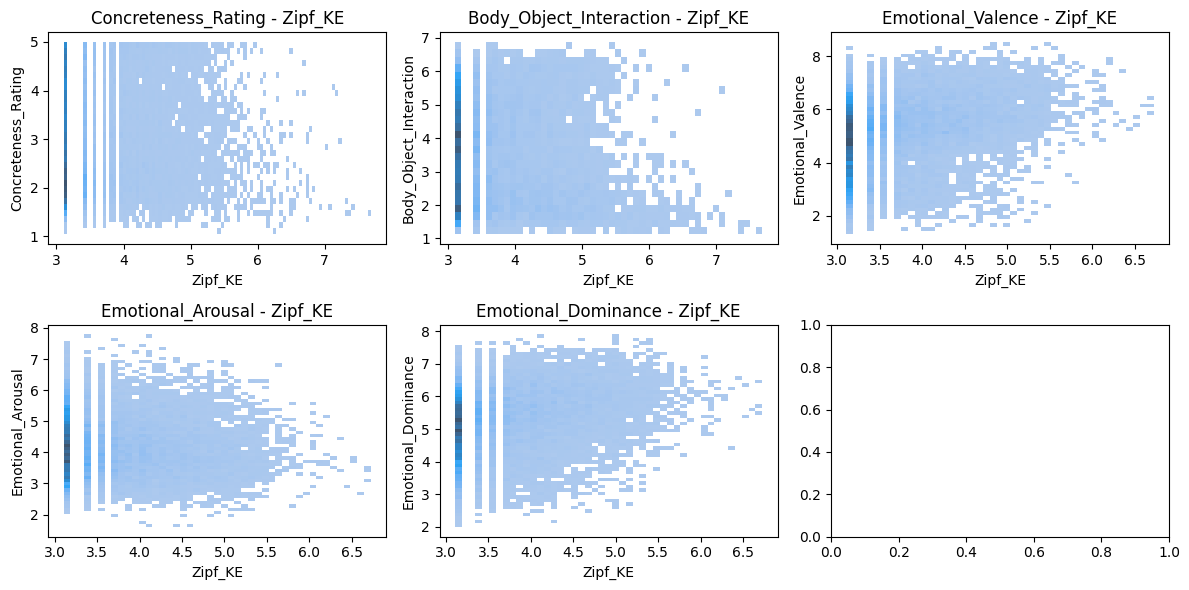

In [34]:
compare_value_distribution(KE_E_final_df, 'Zipf_KE', target_labels)

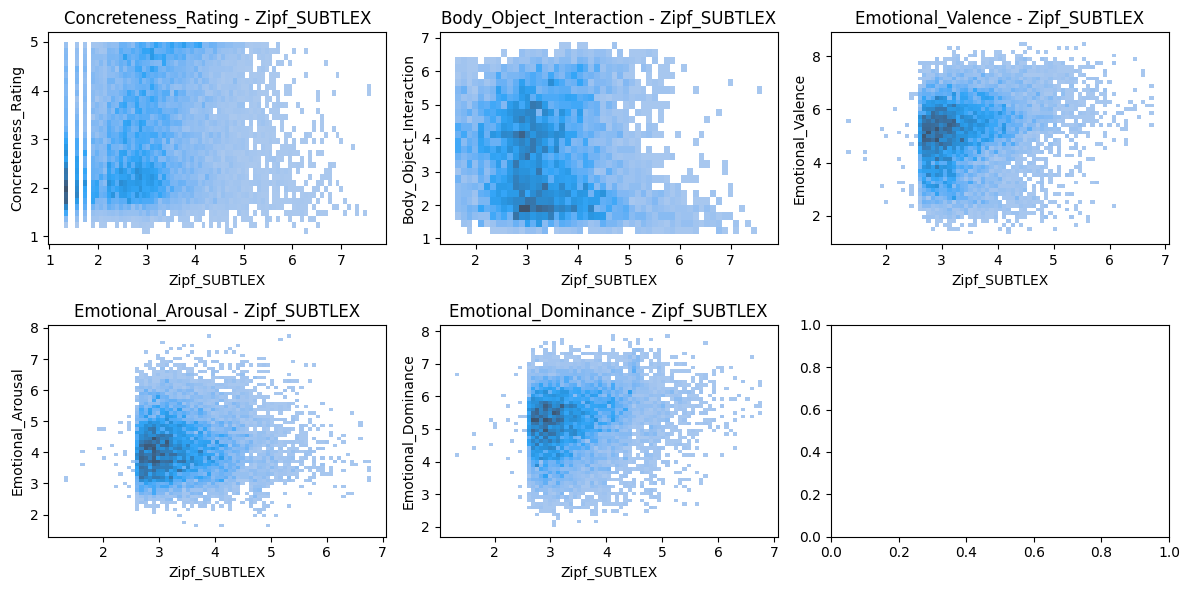

In [35]:
compare_value_distribution(KE_E_final_df, 'Zipf_SUBTLEX', target_labels)

In [37]:
mask = KE_E_final_df['Freq_KE'] > 0
KE_E_final_df[mask][target_labels].describe()

,Concreteness_Rating,Body_Object_Interaction,Emotional_Valence,Emotional_Arousal,Emotional_Dominance
count,10849.000000,4603.000000,7326.000000,7326.000000,7326.000000
mean,3.102076,3.456264,5.325016,4.164764,5.370874
std,1.047830,1.461557,1.291094,0.900126,0.957612
min,1.070000,1.120000,1.470000,1.600000,2.140000
25%,2.190000,2.163500,4.630000,3.520000,4.800000
50%,2.960000,3.208000,5.470000,4.050000,5.470000
75%,4.000000,4.679500,6.210000,4.700000,6.050000
max,5.000000,6.880000,8.530000,7.790000,7.900000


In [ ]:
# 별 차이가 없어 보이는데,,,
mask = KE_E_final_df['Freq_SUBTLEX'] > 0
KE_E_final_df[mask][target_labels].describe()

,Concreteness_Rating,Body_Object_Interaction,Emotional_Valence,Emotional_Arousal,Emotional_Dominance
count,22381.000000,8984.000000,12740.000000,12740.000000,12740.000000
mean,3.137017,3.541324,5.077053,4.205265,5.198648
std,1.032668,1.375944,1.277846,0.896478,0.939835
min,1.040000,1.120000,1.300000,1.600000,2.000000
25%,2.220000,2.307000,4.260000,3.550000,4.597500
50%,3.040000,3.476000,5.210000,4.100000,5.280000
75%,4.030000,4.640000,5.950000,4.760000,5.850000
max,5.000000,6.880000,8.530000,7.790000,7.900000
